In [5]:
from cardroom.briscola.game.env import BriscolaEnv
from cardroom.briscola.game.player import BriscolaPlayer
from cardroom.briscola.agents.agent import Agent
from cardroom.briscola.agents.random import RandomAgent
from cardroom.briscola.agents.bot import BotAgent
from cardroom.briscola.agents.donatello import DonatelloAgent
from cardroom.briscola.agents.evaluation.evaluate_agent import AgentEvaluator
from cardroom.briscola.agents.evaluation.evaluate_game import DeckMetricsEvaluator
from cardroom.briscola.utils.scoring import play_n_games
from IPython.display import clear_output

Set up agent to be evaluated and run evalation

In [16]:
agents = [
    RandomAgent(),
    BotAgent(),
    DonatelloAgent(name="Donatello200_random_nobelief", simulations=200, rollout_policy="random", use_belief=False),
    DonatelloAgent(name="Donatello2k_random_nobelief", simulations=2000, rollout_policy="random", use_belief=False),
    DonatelloAgent(name="Donatello200_bot_nobelief", simulations=200, rollout_policy="bot", use_belief=False),
    DonatelloAgent(name="Donatello2k_bot_nobelief", simulations=2000, rollout_policy="bot", use_belief=False),
    DonatelloAgent(name="Donatello200_random", simulations=200, rollout_policy="random", use_belief=True),
    DonatelloAgent(name="Donatello2k_random", simulations=2000, rollout_policy="random", use_belief=True),
    DonatelloAgent(name="Donatello200_bot", simulations=200, rollout_policy="bot", use_belief=True),
    DonatelloAgent(name="Donatello2k_bot", simulations=2000, rollout_policy="bot", use_belief=True)
]

n_games = 500

In [6]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import List, Dict, Tuple, Any, Optional

# Assumptions:
# - Each Agent has a .name attribute (stringifiable).
# - play_n_games([a0, a1], n_games) -> (winners, final_states)
#   winners: list[str] of length n_games, with values {a0.name, a1.name, "Draw"}.
#   final_states: list[Any] (arbitrary objects), one per game in same order.

@dataclass
class MatchResult:
    agent_i: str
    agent_j: str
    wins_i: int
    wins_j: int
    draws: int
    games: int

class AgentChampionship:
    def __init__(self, agents: List, n_games: int = 500, seed: int = 42):
        self.agents = agents
        self.n_games = n_games
        self.rng = np.random.default_rng(seed)
        self.agent_names = [str(getattr(a, "name", f"Agent{idx}")) for idx, a in enumerate(agents)]
        # Results
        self.h2h_wins: Optional[pd.DataFrame] = None      # rows beat columns (counts)
        self.h2h_games: Optional[pd.DataFrame] = None     # total non-draw games per pair (used for rates)
        self.h2h_draws: Optional[pd.DataFrame] = None     # draw counts per pair
        self.h2h_rates: Optional[pd.DataFrame] = None     # win rate rows vs columns (exclude draws)
        self.standings: Optional[pd.DataFrame] = None     # overall table with ranks
        self.match_log: List[MatchResult] = []            # per pairing summary
        self.final_states_by_pair: Dict[Tuple[str, str], List[Any]] = {}  # store all final states per pairing
        self.all_final_states: List[Tuple[str, str, Any]] = []            # flat list (i_name, j_name, state)

    def play_match(self, a0, a1) -> Tuple[List[str], List[Any]]:
        winners, final_states = play_n_games([a0, a1], self.n_games)
        return winners, final_states

    def run(self) -> None:
        n = len(self.agents)
        idx = self.agent_names

        wins_matrix = np.zeros((n, n), dtype=int)   # wins for row vs col
        games_matrix = np.zeros((n, n), dtype=int)  # non-draw games row vs col (for win-rate denominator)
        draws_matrix = np.zeros((n, n), dtype=int)  # draws counted symmetrically

        for i, j in itertools.combinations(range(n), 2):
            a_i, a_j = self.agents[i], self.agents[j]
            name_i, name_j = self.agent_names[i], self.agent_names[j]
            winners, final_states = self.play_match(a_i, a_j)

            # store final states
            self.final_states_by_pair[(name_i, name_j)] = list(final_states)
            for fs in final_states:
                self.all_final_states.append((name_i, name_j, fs))

            # aggregate outcomes
            wins_i = sum(1 for w in winners if w == name_i)
            wins_j = sum(1 for w in winners if w == name_j)
            draws = sum(1 for w in winners if isinstance(w, str) and w.lower() == "draw")
            total = wins_i + wins_j + draws

            # fill symmetric matrices
            wins_matrix[i, j] += wins_i
            wins_matrix[j, i] += wins_j
            # games used for rate exclude draws
            games_matrix[i, j] += (wins_i + wins_j)
            games_matrix[j, i] += (wins_i + wins_j)
            # draws stored symmetrically
            draws_matrix[i, j] += draws
            draws_matrix[j, i] += draws

            self.match_log.append(MatchResult(
                agent_i=name_i, agent_j=name_j,
                wins_i=wins_i, wins_j=wins_j, draws=draws, games=total
            ))

        # DataFrames
        self.h2h_wins = pd.DataFrame(wins_matrix, index=idx, columns=idx)
        self.h2h_games = pd.DataFrame(games_matrix, index=idx, columns=idx)
        self.h2h_draws = pd.DataFrame(draws_matrix, index=idx, columns=idx)

        # Win rates row vs column, excluding draws in the denominator
        with np.errstate(divide="ignore", invalid="ignore"):
            rates = wins_matrix / np.where(games_matrix == 0, 1, games_matrix)
        np.fill_diagonal(rates, np.nan)
        self.h2h_rates = pd.DataFrame(rates, index=idx, columns=idx)

        # Standings:
        # - total wins (sum of row across opponents)
        # - total non-draw games and total games (for overall win rate and draw rate)
        total_wins = self.h2h_wins.sum(axis=1)
        total_non_draw_games = self.h2h_games.sum(axis=1)
        total_draws = self.h2h_draws.sum(axis=1) / 2  # each draw counted twice symmetrically
        total_games = total_non_draw_games + total_draws

        overall_win_rate = total_wins / np.where(total_non_draw_games == 0, 1, total_non_draw_games)
        draw_rate = total_draws / np.where(total_games == 0, 1, total_games)
        points = total_wins + 0.5 * total_draws  # 1 for win, 0.5 for draw

        self.standings = (
            pd.DataFrame({
                "agent": idx,
                "wins": total_wins.values.astype(int),
                "draws": total_draws.values.astype(int),
                "games": total_games.values.astype(int),
                "non_draw_games": total_non_draw_games.values.astype(int),
                "win_rate_excl_draws": overall_win_rate.values,
                "draw_rate": draw_rate.values,
                "points": points.values
            })
            .sort_values(["points", "win_rate_excl_draws", "wins"], ascending=[False, False, False])
            .reset_index(drop=True)
        )
        self.standings["rank"] = np.arange(1, len(self.standings) + 1)

    def plot_heatmap(self, annot: bool = True, cmap: str = "viridis") -> None:
        if self.h2h_rates is None:
            raise RuntimeError("Run the championship first.")
        plt.figure(figsize=(1.1 * len(self.agent_names), 0.9 * len(self.agent_names)))
        sns.heatmap(self.h2h_rates, annot=annot, fmt=".2f", cmap=cmap, vmin=0.0, vmax=1.0,
                    cbar=True, linewidths=0.5, linecolor="white")
        plt.title("Head-to-Head Win Rates (row vs column; draws excluded)")
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    def plot_bar_standings(self) -> None:
        if self.standings is None:
            raise RuntimeError("Run the championship first.")
        df = self.standings.sort_values("points", ascending=True)
        plt.figure(figsize=(9, max(4, 0.6 * len(df))))
        bars = plt.barh(df["agent"], df["points"])
        for i, (pts, wins, dr, g) in enumerate(zip(df["points"], df["wins"], df["draws"], df["games"])):
            plt.text(pts + 0.02, i, f"{pts:.1f} pts  (W:{wins} D:{int(dr)} / {g})", va="center")
        plt.xlabel("Points (win=1, draw=0.5)")
        plt.title("Championship Standings")
        plt.tight_layout()
        plt.show()

    def summary(self) -> pd.DataFrame:
        if self.standings is None:
            raise RuntimeError("Run the championship first.")
        cols = ["rank", "agent", "points", "wins", "draws", "games", "win_rate_excl_draws", "draw_rate"]
        return self.standings[cols].copy()


In [17]:
championship = AgentChampionship(agents, n_games)
championship.run()

Playing games... (RandomAgent wins: 74 | BotAgent wins: 421 | Draws: 0): 100%|██████████| 500/500 [00:00<00:00, 1789.96it/s]


Final Summary:
RandomAgent wins: 74
BotAgent wins: 421
Draws: 5


Playing games... (RandomAgent wins: 39 | Donatello200_random_nobelief wins: 457 | Draws: 0): 100%|██████████| 500/500 [07:33<00:00,  1.10it/s]


Final Summary:
RandomAgent wins: 39
Donatello200_random_nobelief wins: 457
Draws: 4


Playing games... (RandomAgent wins: 23 | Donatello2k_random_nobelief wins: 473 | Draws: 0): 100%|██████████| 500/500 [2:00:26<00:00, 14.45s/it]  


Final Summary:
RandomAgent wins: 23
Donatello2k_random_nobelief wins: 473
Draws: 4


Playing games... (RandomAgent wins: 9 | Donatello200_bot_nobelief wins: 146 | Draws: 0):  31%|███       | 156/500 [01:28<03:14,  1.77it/s]


KeyboardInterrupt: 

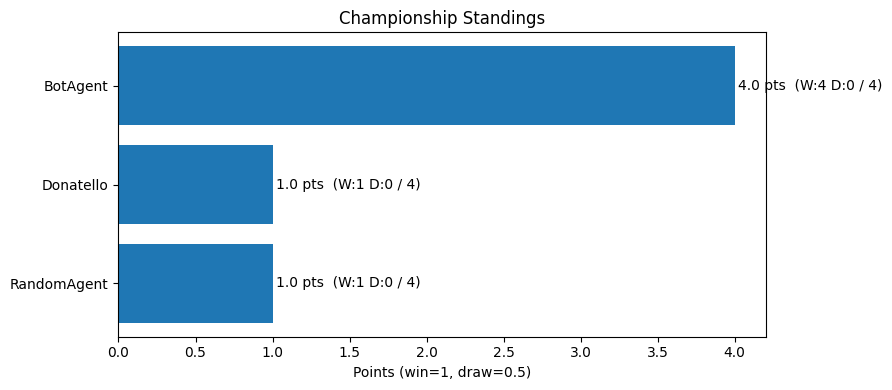

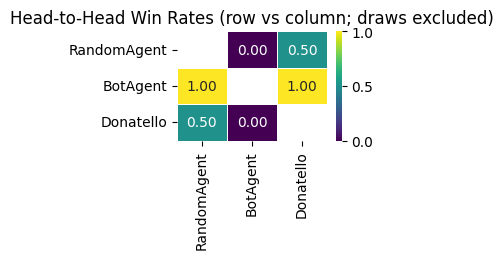

In [ ]:
championship.plot_bar_standings()
championship.plot_heatmap()